In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import genextreme
from scipy.special import gamma as gamma_func
from math import factorial
import pandas as pd

In [2]:
N = 1000
# Dataset 1: Frechet
mu    = 70
alpha = 10
gamma = 0.3
data1 = genextreme.rvs(c=-gamma, loc=mu, scale=alpha, size=N, random_state=42)

# Dataset 2: Weibull
mu    = 70
alpha = 10
gamma = -0.3
data2 = genextreme.rvs(c=-gamma, loc=mu, scale=alpha, size=N, random_state=42)

pd.DataFrame(data1, columns=["value"]).to_csv("gev_data1_param1.csv", index=False)
pd.DataFrame(data2, columns=["value"]).to_csv("gev_data2_param2.csv", index=False)

print("Files created:")
print("gev_data1_param1.csv")
print("gev_data2_param2.csv")

Files created:
gev_data1_param1.csv
gev_data2_param2.csv


In [3]:
#Load Data
df1   = pd.read_csv('gev_data1_param1.csv')
df2   = pd.read_csv('gev_data2_param2.csv')
data1 = df1['value'].values 
data2 = df2['value'].values

In [4]:
# Helper functions
 
def weibull_plotting_positions(n):
    ranks = np.arange(1, n + 1)
    P = ranks / (n + 1)
    return P
 
 
def gev_pdf(x, mu, alpha, gamma):
    if abs(gamma) < 1e-10:
        y = (x - mu) / alpha
        return (1.0 / alpha) * np.exp(-y) * np.exp(-np.exp(-y))
    else:
        inner = 1.0 + gamma * (x - mu) / alpha
        if inner <= 0:
            return 0.0
        return (1.0 / alpha) * inner ** (-(1.0 / gamma + 1.0)) * np.exp(-inner ** (-1.0 / gamma))
 
 
def gev_cdf(x, mu, alpha, gamma):
    if abs(gamma) < 1e-10:
        y = (x - mu) / alpha
        return np.exp(-np.exp(-y))
    else:
        inner = 1.0 + gamma * (x - mu) / alpha
        if inner <= 0:
            return 0.0
        return np.exp(-inner ** (-1.0 / gamma))
 
 
def order_statistic_variance(m, N, mu, alpha, gamma):
    Pm = m / (N + 1)
    spread = 4.0 * np.sqrt(Pm * (1.0 - Pm) / (N + 2))
 
    p_lo = max(1e-6, Pm - spread)
    p_hi = min(1.0 - 1e-6, Pm + spread)
 
    x_lo = genextreme.ppf(p_lo, -gamma, loc=mu, scale=alpha)
    x_hi = genextreme.ppf(p_hi, -gamma, loc=mu, scale=alpha)
    x_grid = np.linspace(x_lo, x_hi, 200)
 
    F_vals = np.array([gev_cdf(x, mu, alpha, gamma) for x in x_grid])
    f_vals = np.array([gev_pdf(x, mu, alpha, gamma) for x in x_grid])
 
    coeff = factorial(N) / (factorial(m - 1) * factorial(N - m))
    fm_vals = coeff * F_vals ** (m - 1) * (1.0 - F_vals) ** (N - m) * f_vals
 
    mean_m = np.trapezoid(x_grid * fm_vals, x_grid)
    var_m = np.trapezoid((x_grid - mean_m) ** 2 * fm_vals, x_grid)
 
    return max(var_m, 1e-12)

In [5]:
# Fitting methods
 
def fit_vwls(data, max_iterations=20, beta=0.001):
    x = np.sort(data)
    N = len(x)
    P = weibull_plotting_positions(N)
 
    weights = np.ones(N) / N
    y_gumbel = -np.log(-np.log(P))
    coeffs = np.polyfit(y_gumbel, x, 1)
    params = np.array([coeffs[1], coeffs[0], 0.0])
    # params = [mu, alpha, gamma]
 
    for iteration in range(max_iterations):
 
        mu = params[0]
        alpha = params[1]
        gamma = params[2]
 
        variances = []
        for m in range(1, N + 1):
            try:
                var_m = order_statistic_variance(m, N, mu, alpha, gamma)
            except Exception:
                var_m = 1.0
            variances.append(var_m)
 
        variances = np.array(variances)
 
        w = 1.0 / variances
        w = w / w.sum()
 
        def objective(params_opt):
            mu_opt, alpha_opt, gamma_opt = params_opt
            if alpha_opt <= 0:
                return 1e12
            xi_opt = genextreme.ppf(P, -gamma_opt, loc=mu_opt, scale=alpha_opt)
            residuals = x - xi_opt
            return np.sum(w * residuals ** 2)
 
        result = minimize(objective, params, method='Nelder-Mead',
                          options={'xatol': 1e-6, 'fatol': 1e-8, 'maxiter': 2000})
 
        new_params = result.x
 
        mu_new = new_params[0]
        alpha_new = new_params[1]
        gamma_new = new_params[2]
 
        xi_vals = genextreme.ppf(P, -gamma_new, loc=mu_new, scale=alpha_new)
 
        k = 0
        while k < N - 5:
            denom = xi_vals[-1] - xi_vals[k]
            if denom < 1e-12:
                k += 1
                continue
            ratio = (xi_vals[k + 1] - xi_vals[k]) / denom
            if ratio < beta:
                k += 1
            else:
                break
 
        if k > 0:
            idx = np.arange(k, N)
            x_sub = x[idx]
            P_sub = P[idx]
            w_sub = w[idx]
            w_sub = w_sub / w_sub.sum()
 
            def objective_sub(params_opt):
                mu_opt, alpha_opt, gamma_opt = params_opt
                if alpha_opt <= 0:
                    return 1e12
                xi_opt = genextreme.ppf(P_sub, -gamma_opt, loc=mu_opt, scale=alpha_opt)
                residuals = x_sub - xi_opt
                return np.sum(w_sub * residuals ** 2)
 
            result = minimize(objective_sub, new_params, method='Nelder-Mead',
                              options={'xatol': 1e-6, 'fatol': 1e-8, 'maxiter': 2000})
 
            new_params = result.x
 
        if np.max(np.abs(new_params - params)) < 1e-5:
            params = new_params
            break
 
        params = new_params
 
    mu, alpha, gamma = params
    return mu, max(alpha, 1e-6), gamma
 
 
def fit_mle(data):
    x = np.sort(data)
    # use L-moments as starting point so MLE converges correctly
    mu0, alpha0, gamma0 = fit_lmoments(data)
    c, mu, alpha = genextreme.fit(x, -gamma0, loc=mu0, scale=alpha0)
    gamma = -c
    return mu, alpha, gamma
 
 
def fit_pwm(data):
    x = np.sort(data)
    n = len(x)
    P = weibull_plotting_positions(n)
 
    b0 = np.mean(x)
    b1 = np.mean(x * P)
    b2 = np.mean(x * P ** 2)
 
    c = (2 * b1 - b0) / (3 * b2 - b0) - np.log(2) / np.log(3) # the formula 7.859c + 2.9554c^2 gives Hosking's k where k>0 means Frechet
    
    k = 7.859 * c + 2.9554 * c ** 2
    gamma = -k
 
    if abs(gamma) < 1e-6:
        alpha = (b0 - 2 * b1) / (-np.log(2))
        mu = b0 + alpha * 0.5772
    else:
        g = gamma_func(1 + k)
        denom = g * (1 - 2 ** (-k))
        if abs(denom) < 1e-10:
            return np.mean(x), np.std(x), 0.0
        alpha = k * (2 * b1 - b0) / denom
        mu = b0 - alpha * (1 - g) / k
 
    return mu, max(float(alpha), 1e-6), float(gamma)
 
 
def fit_lmoments(data):
    x = np.sort(data)
    n = len(x)
    c = np.arange(n)
 
    b0 = np.mean(x)
    b1 = np.sum(c / (n - 1) * x) / n
    b2 = np.sum(c * (c - 1) / ((n - 1) * (n - 2)) * x) / n
 
    l1 = b0
    l2 = 2 * b1 - b0
    l3 = 6 * b2 - 6 * b1 + b0
 
    if abs(l2) < 1e-10:
        return np.mean(x), np.std(x), 0.0
 
    t3 = l3 / l2
    z = 2 / (3 + t3) - np.log(2) / np.log(3)
 
    # same sign convention fix as PWM
    k = 7.859 * z + 2.9554 * z ** 2
    gamma = -k
 
    if abs(gamma) < 1e-6:
        alpha = l2 / np.log(2)
        mu = l1 - 0.5772 * alpha
    else:
        g = gamma_func(1 + k)
        alpha = k * l2 / (g * (1 - 2 ** (-k)))
        mu = l1 - alpha * (1 - g) / k
 
    return mu, max(float(alpha), 1e-6), float(gamma)

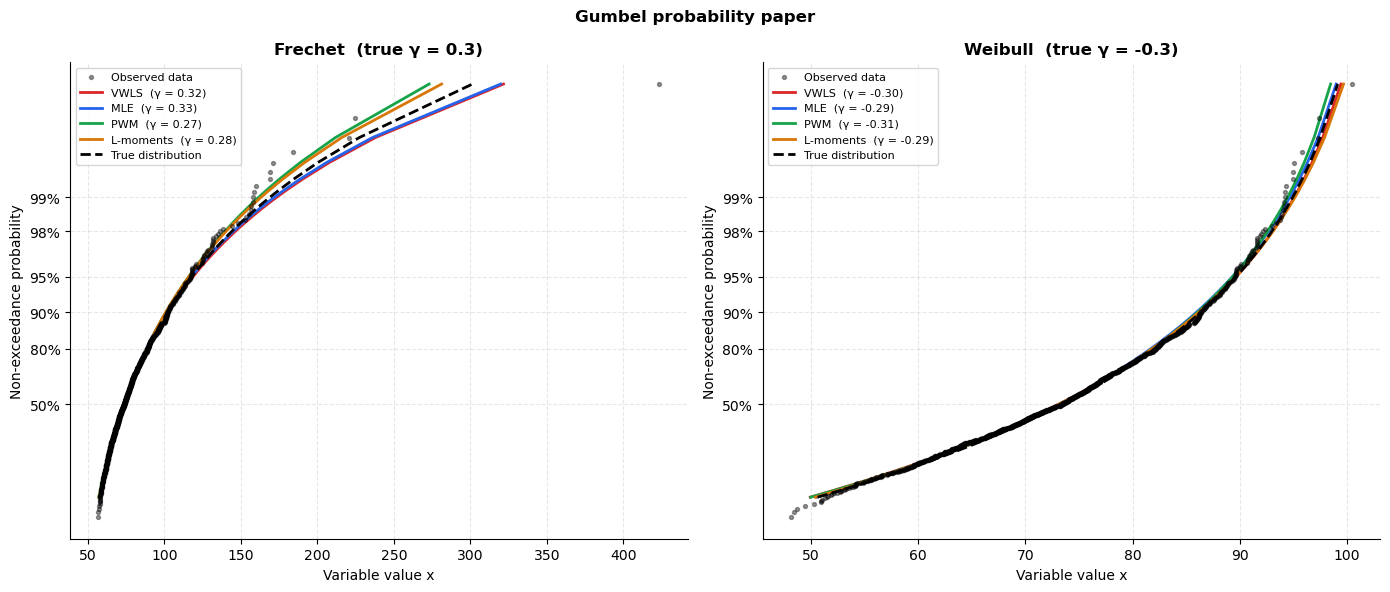

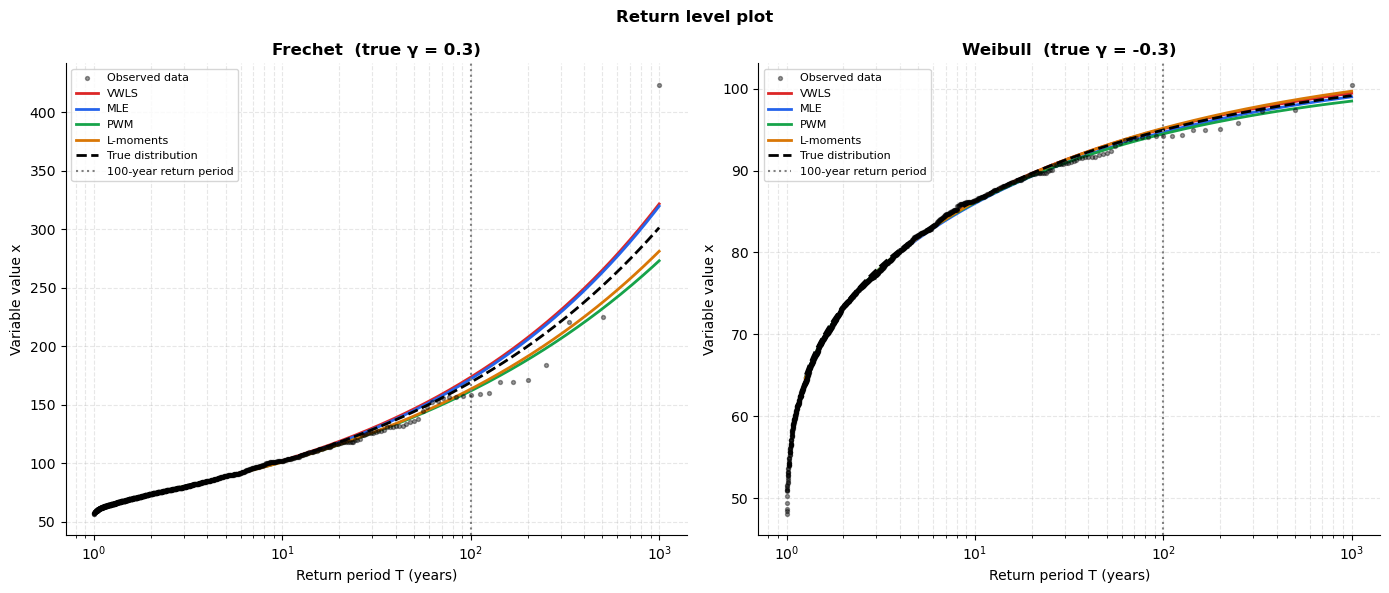

In [6]:
# Fit all methods

true_params = {
    'Frechet': (70, 10,  0.3),
    'Weibull': (70, 10, -0.3),
}
 
datasets = {
    'Frechet': data1,
    'Weibull': data2,
}
 
all_fits = {}
 
for dist_name, data in datasets.items():
    fits = {}
    fits['VWLS']      = fit_vwls(data)
    fits['MLE']       = fit_mle(data)
    fits['PWM']       = fit_pwm(data)
    fits['L-moments'] = fit_lmoments(data)
    all_fits[dist_name] = fits
 
colors = {
    'VWLS':      '#DC2626',  # red
    'MLE':       '#2563EB',  # blue
    'PWM':       '#16A34A',  # green
    'L-moments': '#D97706',  # amber
}
 
 
# Plot 1: Gumbel probability paper
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
for ax, (dist_name, data) in zip(axes, datasets.items()):
 
    x_sorted = np.sort(data)
    n = len(x_sorted)
    P = weibull_plotting_positions(n)
    y_data = -np.log(-np.log(P))
 
    ax.scatter(x_sorted, y_data, color='black', s=8, alpha=0.4, zorder=5, label='Observed data')
 
    p_line = np.linspace(0.01, 0.999, 500)
    y_line = -np.log(-np.log(p_line))
 
    for method, (mu, alpha, shape) in all_fits[dist_name].items():
        x_fit = genextreme.ppf(p_line, -shape, loc=mu, scale=alpha)
        ax.plot(x_fit, y_line, color=colors[method], linewidth=2,
                label=f'{method}  (γ = {shape:.2f})')
 
    true_mu, true_alpha, true_shape = true_params[dist_name]
    x_true = genextreme.ppf(p_line, -true_shape, loc=true_mu, scale=true_alpha)
    ax.plot(x_true, y_line, color='black', linewidth=2, linestyle='--', label='True distribution')
 
    prob_labels = [0.5, 0.8, 0.9, 0.95, 0.98, 0.99]
    y_ticks = [-np.log(-np.log(p)) for p in prob_labels]
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f'{int(p * 100)}%' for p in prob_labels])
    ax.set_title(f'{dist_name}  (true γ = {true_params[dist_name][2]})', fontweight='bold')
    ax.set_xlabel('Variable value x')
    ax.set_ylabel('Non-exceedance probability')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
 
fig.suptitle('Gumbel probability paper', fontweight='bold')
plt.tight_layout()
plt.savefig('plot1_gumbel_paper.png', dpi=150, bbox_inches='tight')
plt.show()
 
 
# Plot 2: Return level plot
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
return_periods = np.logspace(0.1, 3, 300)
exc_probs = 1 - 1 / return_periods
 
for ax, (dist_name, data) in zip(axes, datasets.items()):
 
    x_sorted = np.sort(data)
    n = len(x_sorted)
    P = weibull_plotting_positions(n)
    emp_T = 1 / (1 - P)
 
    ax.scatter(emp_T, x_sorted, color='black', s=8, alpha=0.4, zorder=5, label='Observed data')
 
    for method, (mu, alpha, shape) in all_fits[dist_name].items():
        x_fit = genextreme.ppf(exc_probs, -shape, loc=mu, scale=alpha)
        ax.plot(return_periods, x_fit, color=colors[method], linewidth=2, label=method)
 
    true_mu, true_alpha, true_shape = true_params[dist_name]
    x_true = genextreme.ppf(exc_probs, -true_shape, loc=true_mu, scale=true_alpha)
    ax.plot(return_periods, x_true, color='black', linewidth=2, linestyle='--', label='True distribution')
 
    ax.axvline(100, color='gray', linestyle=':', linewidth=1.5, label='100-year return period')
 
    ax.set_xscale('log')
    ax.set_title(f'{dist_name}  (true γ = {true_params[dist_name][2]})', fontweight='bold')
    ax.set_xlabel('Return period T (years)')
    ax.set_ylabel('Variable value x')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, linestyle='--', which='both')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
 
fig.suptitle('Return level plot', fontweight='bold')
plt.tight_layout()
plt.savefig('plot2_return_levels.png', dpi=150, bbox_inches='tight')
plt.show()